# Notebook 1 — Preprocessing & Data Loading Pipeline
## ML4SCI / CERN PrediCT Evaluation Test — Common Task

**Author:** Aditya Parashar  
**Dataset:** COCA — Coronary Calcium and Chest CTs (Stanford AIMI)  


In [5]:
# ============================================================
# ENVIRONMENT SETUP — Run ONCE in terminal before opening notebooks
# ============================================================
#
# Step 1: Create environment with Python 3.8 (NON-NEGOTIABLE VERSION)
#   conda create -n predict_env python=3.8 -y
#   conda activate predict_env
#
# Step 2: Install PyRadiomics via conda (NOT pip — pip fails on Windows due to C extensions)
#   conda install -c radiomics -c conda-forge pyradiomics -y
#
#   If conda install fails with "no viable options" error, use community fork:
#   pip install pyradiomics-bhklab
#
# Step 3: Install all other dependencies
#   pip install SimpleITK==2.2.1 monai pydicom nibabel scipy scikit-learn \
#              matplotlib seaborn pandas numpy tqdm opencv-python torch \
#              umap-learn pyyaml pykwalify statsmodels==0.13.5 jupyterlab ipykernel
#
# Step 4: Register Jupyter kernel
#   python -m ipykernel install --user --name predict_env --display-name "PrediCT Python 3.8"
#
# Step 5: Launch Jupyter and select kernel "PrediCT Python 3.8"
#   jupyter lab
#
# Step 6: Verify PyRadiomics before writing any code
#   import radiomics
#   from radiomics import featureextractor
#   print(radiomics.__version__)  # must print without error
#
# NEVER use base conda environment
# NEVER use Python 3.9 or above for this project
# ALL notebook cells assume predict_env is the active kernel
# ============================================================

## Design Justification

This preprocessing pipeline is specifically tailored for radiomics compatibility 
(Project 2). HU windowing uses center=150 HU and width=700 HU (range −200 to 500 HU), 
chosen to preserve the full calcium density range (130–1000+ HU) while suppressing 
irrelevant soft tissue signal. Resampling to isotropic 1.0 mm³ spacing is mandatory 
for accurate Shape feature computation (Sphericity, Maximum3DDiameter) which require 
equal voxel dimensions in all axes — anisotropic spacing would produce geometrically 
incorrect shape measurements. B-spline interpolation is used for CT volumes to 
preserve HU fidelity; nearest-neighbor is used for binary masks to prevent 
fractional label values. Agatston scoring deliberately uses original 3.0 mm spacing 
to comply with the Agatston 1990 clinical standard, which was validated at this 
specific slice thickness.

HU windowing to [−200, 500] HU was applied for the DataLoader and 
visualization pipeline. PyRadiomics feature extraction operates on 
the masked calcium ROI where voxel values are further discretized 
using a fixed bin width of 25 HU per IBSI guidelines, making the 
precise upper window boundary secondary to the discretization step.

Data augmentation is restricted to geometric transforms (flips, 90° rotations) and 
mild intensity noise (σ=0.01 Gaussian). Elastic deformation, shearing, and aggressive 
intensity transforms are explicitly excluded because they alter voxel-level texture 
statistics and would corrupt GLCM, GLSZM, and GLRLM feature values. The 
WeightedRandomSampler addresses the class imbalance in this cohort (14 mild, 9 
moderate, 7 severe — 0 zero-calcium patients) by oversampling underrepresented 
severity categories during training. The lazy-loading LazyCACSDataset design avoids 
out-of-memory errors by reading preprocessed .npy files from disk per sample rather 
than holding all 30 volumes in RAM simultaneously.

## Imports & Configuration

In [ ]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import pydicom
import SimpleITK as sitk
import cv2
import plistlib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from scipy import ndimage
from sklearn.model_selection import StratifiedShuffleSplit
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler

warnings.filterwarnings('ignore')
os.makedirs('outputs', exist_ok=True)


# SINGLE CONFIG VARIABLE — change this to your data root

DATA_ROOT = r"data"

print(f"Python version: {sys.version}")
print(f"DATA_ROOT: {os.path.abspath(DATA_ROOT)}")

Python version: 3.8.20 (default, Oct  3 2024, 15:19:54) [MSC v.1929 64 bit (AMD64)]
DATA_ROOT: d:\ml4sci2\PrediCT\data


---
## Section 1 — DICOM Loader

Load all DICOM series, sorted by `InstanceNumber` (not filename).  
Extract pixel spacing and slice thickness from DICOM headers.

In [ ]:
def discover_patients(data_root):
    """Dynamically discover patient IDs by intersecting raw folders and XML files."""
    raw_dir = os.path.join(data_root, 'raw')
    xml_dir = os.path.join(data_root, 'calcium_xml')
    
  
    raw_ids = set()
    for name in os.listdir(raw_dir):
        full = os.path.join(raw_dir, name)
        if os.path.isdir(full):
            raw_ids.add(name)
    
    
    xml_ids = set()
    for name in os.listdir(xml_dir):
        if name.endswith('.xml'):
            xml_ids.add(name.replace('.xml', ''))
    
    
    valid_ids = sorted(raw_ids & xml_ids, key=lambda x: int(x))
    
    
    xml_only = xml_ids - raw_ids
    raw_only = raw_ids - xml_ids
    if xml_only:
        print(f"WARNING: XML exists but no DICOM folder for patient(s): {sorted(xml_only, key=lambda x: int(x))}")
    if raw_only:
        print(f"WARNING: DICOM folder exists but no XML for patient(s): {sorted(raw_only, key=lambda x: int(x))}")
    
    print(f"Discovered {len(valid_ids)} valid patients: {valid_ids}")
    return valid_ids

patient_ids = discover_patients(DATA_ROOT)

Discovered 30 valid patients: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30']


In [ ]:
def find_dicom_subfolder(patient_dir):
    """Find the DICOM subfolder (e.g. Pro_Gated_CS_3.0_I30f_3_70%) dynamically."""
    for name in os.listdir(patient_dir):
        sub = os.path.join(patient_dir, name)
        if os.path.isdir(sub):
            
            dcm_files = [f for f in os.listdir(sub) if f.endswith('.dcm')]
            if dcm_files:
                return sub
    
    dcm_files = [f for f in os.listdir(patient_dir) if f.endswith('.dcm')]
    if dcm_files:
        return patient_dir
    raise FileNotFoundError(f"No DICOM files found in {patient_dir}")


def load_patient_dicom(patient_id, data_root):
    """Load DICOM series sorted by InstanceNumber (not filename).
    
    Returns:
        ct_sitk: SimpleITK image of CT volume
        pixel_spacing: (x, y, z) spacing in mm
        sorted_files: list of file paths sorted by InstanceNumber
        slice_thickness: float, slice thickness in mm
    """
    patient_dir = os.path.join(data_root, 'raw', str(patient_id))
    dcm_dir = find_dicom_subfolder(patient_dir)
    
    dcm_files = [os.path.join(dcm_dir, f) for f in os.listdir(dcm_dir) if f.endswith('.dcm')]
    
   
    slices = []
    for f in dcm_files:
        ds = pydicom.dcmread(f, stop_before_pixels=True)
        slices.append((int(ds.InstanceNumber), f))
    
    
    slices.sort(key=lambda x: x[0])
    sorted_files = [f for _, f in slices]
    
    
    reader = sitk.ImageSeriesReader()
    reader.SetFileNames(sorted_files)
    ct_sitk = reader.Execute()
    
    
    pixel_spacing = ct_sitk.GetSpacing()  # (x, y, z) in mm
    
    
    ds0 = pydicom.dcmread(sorted_files[0], stop_before_pixels=True)
    slice_thickness = float(ds0.SliceThickness) if hasattr(ds0, 'SliceThickness') else pixel_spacing[2]
    
    return ct_sitk, pixel_spacing, sorted_files, slice_thickness


pid = patient_ids[0]
ct_sitk, spacing, files, st = load_patient_dicom(pid, DATA_ROOT)
ct_array = sitk.GetArrayFromImage(ct_sitk)
print(f"Patient {pid}: shape={ct_array.shape}, spacing={spacing}, slice_thickness={st}mm")
print(f"  HU range: [{ct_array.min():.0f}, {ct_array.max():.0f}]")

Patient 0: shape=(57, 512, 512), spacing=(0.474609375, 0.474609375, 3.0), slice_thickness=3.0mm
  HU range: [-1024, 1142]


---
## Section 2 — XML Annotation Parser

Parse calcium scoring annotations from Apple plist XML format using Python's stdlib `plistlib`.  
Extract per-slice ROI data: Area, Max HU, artery name, contour points.  
Skip all ROIs where `NumberOfPoints == 0`.

In [ ]:
def parse_calcium_xml(patient_id, data_root):
    """Parse calcium XML annotations for a patient.
    
    Returns:
        list of dicts, one per annotated slice, each containing:
        - 'ImageIndex': int (zero-based index into InstanceNumber-sorted DICOM list)
        - 'ROIs': list of ROI dicts with Area, Max, Mean, Min, Dev, Total, Name, 
                  NumberOfPoints, Point_px
    """
    xml_path = os.path.join(data_root, 'calcium_xml', f'{patient_id}.xml')
    
    with open(xml_path, 'rb') as f:
        plist_data = plistlib.load(f)
    
    annotations = []
    for image_entry in plist_data.get('Images', []):
        slice_info = {
            'ImageIndex': image_entry['ImageIndex'],
            'NumberOfROIs': image_entry.get('NumberOfROIs', 0),
            'ROIs': []
        }
        
        for roi in image_entry.get('ROIs', []):
            n_points = roi.get('NumberOfPoints', 0)
            if n_points == 0:
                continue  
            
            roi_data = {
                'Area': roi.get('Area', 0.0),
                'Max': roi.get('Max', 0.0),
                'Mean': roi.get('Mean', 0.0),
                'Min': roi.get('Min', 0.0),
                'Dev': roi.get('Dev', 0.0),
                'Total': roi.get('Total', 0.0),
                'Name': roi.get('Name', 'Unknown'),
                'NumberOfPoints': n_points,
                'Point_px': roi.get('Point_px', [])
            }
            slice_info['ROIs'].append(roi_data)
        
        annotations.append(slice_info)
    
    return annotations

# Test
annots = parse_calcium_xml(patient_ids[0], DATA_ROOT)
total_rois = sum(len(a['ROIs']) for a in annots)
print(f"Patient {patient_ids[0]}: {len(annots)} annotated slices, {total_rois} valid ROIs")
if total_rois > 0:
    sample_roi = [a['ROIs'][0] for a in annots if a['ROIs']][0]
    print(f"  Sample ROI: artery={sample_roi['Name']}, Area={sample_roi['Area']:.4f} cm², "
          f"Max={sample_roi['Max']:.0f} HU, Points={sample_roi['NumberOfPoints']}")

Patient 0: 2 annotated slices, 1 valid ROIs
  Sample ROI: artery=Right Coronary Artery, Area=0.0293 cm², Max=206 HU, Points=20


---
## Section 3 — Binary Mask Generation from XML

For each annotated slice, parse `Point_px` strings `"(x, y)"` into float coordinates and draw filled polygons using `cv2.fillPoly`.  
**Critical:** `mask_sitk.CopyInformation(ct_sitk)` is **mandatory** for PyRadiomics geometry matching.

In [ ]:
def build_3d_mask(annotations, ct_sitk):
    """Build 3D binary mask from XML annotations.
    
    Args:
        annotations: list from parse_calcium_xml()
        ct_sitk: SimpleITK CT volume image
    
    Returns:
        mask_sitk: SimpleITK image, uint8, label=1, with CopyInformation applied
        mask_array: numpy array (z, y, x), uint8
    """
    ct_array = sitk.GetArrayFromImage(ct_sitk)  # shape: (z, y, x)
    n_slices, height, width = ct_array.shape
    mask_array = np.zeros((n_slices, height, width), dtype=np.uint8)
    
    for entry in annotations:
        slice_idx = entry['ImageIndex']
        
       
        if slice_idx >= n_slices:
            continue
        
        for roi in entry['ROIs']:
            if roi['NumberOfPoints'] == 0:
                continue
            
            
            points = []
            for pt_str in roi['Point_px']:
                x_str, y_str = pt_str.strip('()').split(',')
                x, y = float(x_str.strip()), float(y_str.strip())
                points.append([int(round(x)), int(round(y))])
            
            if len(points) >= 3:
                pts = np.array(points, dtype=np.int32).reshape((-1, 1, 2))
                cv2.fillPoly(mask_array[slice_idx], [pts], color=1)
    
    
    mask_sitk = sitk.GetImageFromArray(mask_array)
    mask_sitk.CopyInformation(ct_sitk)
    
    return mask_sitk, mask_array

# Test
annots0 = parse_calcium_xml(patient_ids[0], DATA_ROOT)
ct0, _, _, _ = load_patient_dicom(patient_ids[0], DATA_ROOT)
mask0_sitk, mask0_arr = build_3d_mask(annots0, ct0)
print(f"Patient {patient_ids[0]}: mask shape={mask0_arr.shape}, "
      f"non-zero voxels={mask0_arr.sum()}, "
      f"annotated slices={np.any(mask0_arr, axis=(1,2)).sum()}")

Patient 0: mask shape=(57, 512, 512), non-zero voxels=31, annotated slices=1


---
## Section 4 — HU Windowing

Calcium scoring CT window: **center=150 HU, width=700 HU** → range [−200, 500] HU.  
Clip and normalize to [0, 1] range.

In [ ]:
def apply_hu_window(ct_array, window_center=150, window_width=700):
    """Apply HU windowing for cardiac calcium scoring CT.
    
    Args:
        ct_array: numpy array of HU values
        window_center: HU center (default 150)
        window_width: HU width (default 700)
    
    Returns:
        normalized: array clipped to window and scaled to [0, 1]
    """
    lower = window_center - window_width / 2  
    upper = window_center + window_width / 2  
    windowed = np.clip(ct_array, lower, upper)
    normalized = (windowed - lower) / (upper - lower)
    return normalized

# Test
ct0_arr = sitk.GetArrayFromImage(ct0).astype(np.float32)
ct0_windowed = apply_hu_window(ct0_arr)
print(f"Before windowing: mean={ct0_arr.mean():.1f}, std={ct0_arr.std():.1f}, "
      f"range=[{ct0_arr.min():.0f}, {ct0_arr.max():.0f}]")
print(f"After windowing:  mean={ct0_windowed.mean():.4f}, std={ct0_windowed.std():.4f}, "
      f"range=[{ct0_windowed.min():.4f}, {ct0_windowed.max():.4f}]")

Before windowing: mean=-167.4, std=343.5, range=[-1024, 1142]
After windowing:  mean=0.2283, std=0.1919, range=[0.0000, 1.0000]


---
## Section 5 — Resampling to Isotropic 1.0 mm³

Resample both CT image and mask to isotropic 1.0 mm³ spacing using SimpleITK.
- **CT image**: B-spline interpolation (preserves HU values)
- **Mask**: NearestNeighbor (preserves binary values)

> **Important:** Agatston scoring uses ORIGINAL spacing. PyRadiomics uses RESAMPLED volumes.

In [ ]:
def resample_to_isotropic(ct_sitk, mask_sitk=None, target_spacing=(1.0, 1.0, 1.0)):
    """Resample CT and optionally mask to isotropic spacing.
    
    Args:
        ct_sitk: SimpleITK CT image
        mask_sitk: SimpleITK binary mask (optional)
        target_spacing: target voxel spacing in mm
    
    Returns:
        ct_resampled, (mask_resampled if mask_sitk provided)
    """
    original_spacing = ct_sitk.GetSpacing()
    original_size = ct_sitk.GetSize()
    
    new_size = [
        int(round(osz * ospc / tspc))
        for osz, ospc, tspc in zip(original_size, original_spacing, target_spacing)
    ]
    
    resample = sitk.ResampleImageFilter()
    resample.SetOutputSpacing(target_spacing)
    resample.SetSize(new_size)
    resample.SetOutputDirection(ct_sitk.GetDirection())
    resample.SetOutputOrigin(ct_sitk.GetOrigin())
    resample.SetTransform(sitk.Transform())
    
    # CT: B-spline interpolation
    resample.SetInterpolator(sitk.sitkBSpline)
    resample.SetDefaultPixelValue(-1000)
    ct_resampled = resample.Execute(ct_sitk)
    
    if mask_sitk is None:
        return ct_resampled
    
    
    resample.SetInterpolator(sitk.sitkNearestNeighbor)
    resample.SetDefaultPixelValue(0)
    mask_resampled = resample.Execute(mask_sitk)
    
    return ct_resampled, mask_resampled

# Test
ct0_res, mask0_res = resample_to_isotropic(ct0, mask0_sitk)
print(f"Original:  size={ct0.GetSize()}, spacing={ct0.GetSpacing()}")
print(f"Resampled: size={ct0_res.GetSize()}, spacing={ct0_res.GetSpacing()}")
print(f"Mask resampled non-zero: {sitk.GetArrayFromImage(mask0_res).sum()}")

Original:  size=(512, 512, 57), spacing=(0.474609375, 0.474609375, 3.0)
Resampled: size=(243, 243, 171), spacing=(1.0, 1.0, 1.0)
Mask resampled non-zero: 18


---
## Section 6 — Agatston Score Calculation

Agatston scoring per Agatston AS et al. *JACC* 1990;15(4):827-832.

Uses **original 3.0 mm spacing** volumes (before resampling). For each ROI:
- Density weight from Max HU: 130–199 → 1, 200–299 → 2, 300–399 → 3, ≥400 → 4
- Contribution = Area (cm²) × 100 × density_weight

Risk categories (AHA/CAC-DRS): 0, 1-99, 100-399, 400+

In [ ]:
def compute_agatston_from_annotations(annotations):
    """Compute Agatston score and per-artery breakdown from XML annotations.
    
    Uses Area (cm²) and Max HU directly from XML — original spacing data.
    
    Returns:
        total_score: float, total Agatston score
        artery_scores: dict with keys 'RCA', 'LAD', 'LCx'
        category: str risk category
    """
    artery_map = {
        'Right Coronary Artery': 'RCA',
        'Left Anterior Descending': 'LAD',
        'Left Circumflex': 'LCx',
        'Left Main': 'LCx',  
    }
    artery_scores = {'RCA': 0.0, 'LAD': 0.0, 'LCx': 0.0}
    
    for entry in annotations:
        for roi in entry['ROIs']:
            if roi['NumberOfPoints'] == 0 or roi['Max'] < 130:
                continue
            
            max_hu = roi['Max']
            area_cm2 = roi['Area']
            
            
            if max_hu < 200:
                weight = 1
            elif max_hu < 300:
                weight = 2
            elif max_hu < 400:
                weight = 3
            else:
                weight = 4
            
            
            score = area_cm2 * 100 * weight
            
            artery_key = artery_map.get(roi['Name'], 'LCx')
            artery_scores[artery_key] += score
    
    total_score = sum(artery_scores.values())
    
    # Risk categories
    if total_score == 0:
        category = '0'
    elif total_score < 100:
        category = '1-99'
    elif total_score < 400:
        category = '100-399'
    else:
        category = '400+'
    
    return total_score, artery_scores, category

In [ ]:
# ── Process ALL patients — save to disk to avoid OOM ──
import gc


for _var in ['ct_sitk', 'ct_array', 'ct0', 'ct0_arr', 'ct0_windowed',
             'mask0_sitk', 'mask0_arr', 'ct0_res', 'mask0_res',
             'annots', 'annots0', 'spacing', 'files', 'st', 'pid']:
    if _var in dir():
        try:
            exec(f'del {_var}')
        except:
            pass
gc.collect()
print("Freed test variables from Sections 1-5")

PREPROC_DIR = os.path.join('outputs', 'preprocessed')
os.makedirs(PREPROC_DIR, exist_ok=True)

print("=" * 70)
print("Processing all patients (saving to disk)...")
print("=" * 70)

all_patient_data = {}  
agatston_records = []

for pid in tqdm(patient_ids, desc="Loading patients"):
    try:
        # Step 1: Load DICOM 
        ct_sitk_i, spacing_i, _, slice_thickness_i = load_patient_dicom(pid, DATA_ROOT)
        ct_arr_i = sitk.GetArrayFromImage(ct_sitk_i).astype(np.float32)
        
        # Step 2: Parse XML
        annotations_i = parse_calcium_xml(pid, DATA_ROOT)
        
        #Step 3: Build mask=
        mask_sitk_i, mask_arr_i = build_3d_mask(annotations_i, ct_sitk_i)
        
        #Step 4: Compute stats from original (before freeing)
        ct_wind_i = apply_hu_window(ct_arr_i)
        stats_i = {
            'orig_shape': ct_arr_i.shape,
            'hu_mean_raw': round(float(ct_arr_i.mean()), 1),
            'hu_std_raw': round(float(ct_arr_i.std()), 1),
            'hu_mean_wind': round(float(ct_wind_i.mean()), 4),
            'hu_std_wind': round(float(ct_wind_i.std()), 4),
            'mask_nonzero': int(mask_arr_i.sum()),
            'mask_best_slice': int(np.argmax(mask_arr_i.sum(axis=(1, 2)))),
        }
        
        del ct_arr_i, ct_wind_i
        gc.collect()
        
       
        ct_res_i, mask_res_i = resample_to_isotropic(ct_sitk_i, mask_sitk_i)
        
        
        del ct_sitk_i, mask_sitk_i, mask_arr_i
        gc.collect()
        
        # Step 6: Window resampled CT and save to disk 
        ct_res_arr_i = sitk.GetArrayFromImage(ct_res_i).astype(np.float32)
        del ct_res_i
        ct_res_wind_i = apply_hu_window(ct_res_arr_i)
        del ct_res_arr_i
        
        mask_res_arr_i = sitk.GetArrayFromImage(mask_res_i).astype(np.float32)
        del mask_res_i
        
        np.save(os.path.join(PREPROC_DIR, f'{pid}_ct.npy'), ct_res_wind_i)
        np.save(os.path.join(PREPROC_DIR, f'{pid}_mask.npy'), mask_res_arr_i)
        
        stats_i['resampled_shape'] = ct_res_wind_i.shape
        del ct_res_wind_i, mask_res_arr_i
        gc.collect()
        
        # Step 7: Agatston score 
        total_score, artery_scores, category = compute_agatston_from_annotations(annotations_i)
        
         
        all_patient_data[pid] = {
            **stats_i,
            'annotations': annotations_i,
            'spacing': spacing_i,
            'slice_thickness': slice_thickness_i,
            'agatston': total_score,
            'category': category,
            'artery_scores': artery_scores,
        }
        
        agatston_records.append({
            'patient_id': pid,
            'agatston_score': round(total_score, 2),
            'category': category,
            'score_rca': round(artery_scores['RCA'], 2),
            'score_lad': round(artery_scores['LAD'], 2),
            'score_lcx': round(artery_scores['LCx'], 2),
        })
        
        print(f"  Patient {pid}: saved {stats_i['resampled_shape']}, Agatston={total_score:.1f}")
        
    except Exception as e:
        print(f"ERROR processing patient {pid}: {e}")
        import traceback; traceback.print_exc()
        
        for v in ['ct_sitk_i','ct_arr_i','ct_wind_i','mask_sitk_i','mask_arr_i',
                  'ct_res_i','mask_res_i','ct_res_arr_i','ct_res_wind_i','mask_res_arr_i']:
            if v in dir(): exec(f'del {v}')
        gc.collect()
        continue

gc.collect()


agatston_df = pd.DataFrame(agatston_records)
agatston_df.to_csv('outputs/agatston_scores.csv', index=False)
print(f"\nSaved outputs/agatston_scores.csv ({len(agatston_df)} patients)")
print(f"Preprocessed .npy files saved to {PREPROC_DIR}/")
print(f"\nAgatston Score Summary:")
print(agatston_df.to_string(index=False))

Freed test variables from Sections 1-5
Processing all patients (saving to disk)...


Loading patients:   3%|▎         | 1/30 [00:04<02:18,  4.79s/it]

  Patient 0: saved (171, 243, 243), Agatston=5.9


Loading patients:   7%|▋         | 2/30 [00:09<02:05,  4.48s/it]

  Patient 1: saved (171, 196, 196), Agatston=369.7


...

Loading patients:  97%|█████████▋| 29/30 [01:48<00:04,  4.38s/it]

  Patient 29: saved (171, 178, 178), Agatston=10.6


Loading patients: 100%|██████████| 30/30 [01:52<00:00,  3.76s/it]

  Patient 30: saved (171, 194, 194), Agatston=889.6



Saved outputs/agatston_scores.csv (30 patients)
Preprocessed .npy files saved to outputs\preprocessed/

Agatston Score Summary:
patient_id  agatston_score category  score_rca  score_lad  score_lcx
         0            5.86     1-99       5.86        0.0       0.00
         1          369.73  100-399      75.18        0.0     294.56
         2          113.68  100-399       0.00        0.0     113.68
         3          470.87     400+       0.76        0.0     470.12
         4           27.37     1-99       0.00        0.0      27.37
         5         2298.95     400+    1227.63        0.0    1071.32
         6          341.24  100-399      60.55        0.0     280.69
         7           51.90     1-99       0.00        0.0      51.90
         8           70.10     1-99       0.00        0.0      70.10
         9           72.14     1-99       5.06        0.0      67.08
        10          113.44  100-399      69.24        0.0      44.20
        11          148.84  100-399      51

---
## Section 7 — Stratified Train / Val / Test Split

70/15/15 split stratified by Agatston risk category.  
Uses `sklearn.StratifiedShuffleSplit` to maintain class proportions across splits.

In [ ]:
def stratified_split(patient_ids_list, categories, train_ratio=0.70, val_ratio=0.15, 
                     test_ratio=0.15, random_state=42):
    """Stratified train/val/test split by Agatston category.
    Falls back to simple random split if any class is too small for stratification."""
    ids_arr = np.array(patient_ids_list)
    cats_arr = np.array(categories)
    
    
    from collections import Counter
    cat_counts = Counter(categories)
    min_count = min(cat_counts.values())
    
    if min_count < 2 or len(ids_arr) < 6:
        print(f"WARNING: Class distribution {dict(cat_counts)} too imbalanced for stratification.")
        print("         Falling back to random split (reproducible with seed=42).")
        rng = np.random.RandomState(random_state)
        perm = rng.permutation(len(ids_arr))
        n_train = max(1, int(len(ids_arr) * train_ratio))
        n_val = max(1, int(len(ids_arr) * val_ratio))
        train_idx = perm[:n_train]
        val_idx = perm[n_train:n_train + n_val]
        test_idx = perm[n_train + n_val:]
        if len(test_idx) == 0:
            test_idx = val_idx  
        return ids_arr[train_idx].tolist(), ids_arr[val_idx].tolist(), ids_arr[test_idx].tolist()
    
    
    try:
        sss1 = StratifiedShuffleSplit(n_splits=1, test_size=val_ratio + test_ratio, 
                                       random_state=random_state)
        train_idx, valtest_idx = next(sss1.split(ids_arr, cats_arr))
        
        
        relative_test = test_ratio / (val_ratio + test_ratio)
        valtest_cats = cats_arr[valtest_idx]
        vt_counts = Counter(valtest_cats)
        vt_min = min(vt_counts.values())
        
        if vt_min >= 2:
            sss2 = StratifiedShuffleSplit(n_splits=1, test_size=relative_test, 
                                           random_state=random_state)
            val_idx_rel, test_idx_rel = next(sss2.split(ids_arr[valtest_idx], valtest_cats))
        else:
            
            rng = np.random.RandomState(random_state)
            perm = rng.permutation(len(valtest_idx))
            n_test = max(1, int(len(valtest_idx) * relative_test))
            test_idx_rel = perm[:n_test]
            val_idx_rel = perm[n_test:]
        
        val_idx = valtest_idx[val_idx_rel]
        test_idx = valtest_idx[test_idx_rel]
        return ids_arr[train_idx].tolist(), ids_arr[val_idx].tolist(), ids_arr[test_idx].tolist()
        
    except ValueError as e:
        print(f"WARNING: Stratified split failed ({e}). Using random split.")
        rng = np.random.RandomState(random_state)
        perm = rng.permutation(len(ids_arr))
        n_train = max(1, int(len(ids_arr) * train_ratio))
        n_val = max(1, int(len(ids_arr) * val_ratio))
        train_idx = perm[:n_train]
        val_idx = perm[n_train:n_train + n_val]
        test_idx = perm[n_train + n_val:]
        if len(test_idx) == 0:
            test_idx = val_idx
        return ids_arr[train_idx].tolist(), ids_arr[val_idx].tolist(), ids_arr[test_idx].tolist()


valid_pids = [r['patient_id'] for r in agatston_records]
valid_cats = [r['category'] for r in agatston_records]

train_ids, val_ids, test_ids = stratified_split(valid_pids, valid_cats)

print(f"Train: {len(train_ids)} patients — {train_ids}")
print(f"Val:   {len(val_ids)} patients — {val_ids}")
print(f"Test:  {len(test_ids)} patients — {test_ids}")


print("\nClass distribution per split:")
for split_name, split_ids in [("Train", train_ids), ("Val", val_ids), ("Test", test_ids)]:
    split_cats = [all_patient_data[pid]['category'] for pid in split_ids]
    dist = pd.Series(split_cats).value_counts().sort_index()
    print(f"  {split_name}: {dict(dist)}")

Train: 21 patients — ['30', '23', '18', '19', '1', '4', '15', '10', '29', '24', '7', '22', '0', '3', '13', '2', '11', '20', '9', '28', '25']
Val:   4 patients — ['5', '16', '26', '21']
Test:  5 patients — ['17', '8', '27', '14', '6']

Class distribution per split:
  Train: {'1-99': 10, '100-399': 6, '400+': 5}
  Val: {'1-99': 2, '100-399': 1, '400+': 1}
  Test: {'1-99': 2, '100-399': 2, '400+': 1}


---
## Section 8 — Class Imbalance Handling

Compute inverse-frequency class weights and apply `WeightedRandomSampler` to training DataLoader.

In [ ]:
# Compute class weights (inverse frequency)
train_cats = [all_patient_data[pid]['category'] for pid in train_ids]
cat_counts = pd.Series(train_cats).value_counts()
total_train = len(train_cats)

class_weights = {}
for cat in cat_counts.index:
    class_weights[cat] = total_train / (len(cat_counts) * cat_counts[cat])

print("Inverse-frequency class weights:")
for cat, w in sorted(class_weights.items()):
    print(f"  Category '{cat}': weight = {w:.4f} (count = {cat_counts[cat]})")


sample_weights = [class_weights[cat] for cat in train_cats]
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)
print(f"\nWeightedRandomSampler created with {len(sample_weights)} samples")

Inverse-frequency class weights:
  Category '1-99': weight = 0.7000 (count = 10)
  Category '100-399': weight = 1.1667 (count = 6)
  Category '400+': weight = 1.4000 (count = 5)

WeightedRandomSampler created with 21 samples


---
## Section 9 — MONAI DataLoader

Radiomics-compatible augmentations (no elastic deformation — breaks texture features):
- `RandFlipd` axial axis
- `RandRotate90d`
- `RandGaussianNoised` σ=0.01
- `RandZoomd` range 0.9–1.1

In [ ]:
from torch.utils.data import Dataset

class LazyCACSDataset(Dataset):
    """Lazy-loading dataset that reads .npy from disk per sample.
    Avoids OOM by never holding all volumes in memory."""
    
    def __init__(self, patient_ids_list, patient_data_dict, preproc_dir, augment=False):
        self.pids = patient_ids_list
        self.data = patient_data_dict
        self.preproc_dir = preproc_dir
        self.augment = augment
    
    def __len__(self):
        return len(self.pids)
    
    def __getitem__(self, idx):
        pid = self.pids[idx]
        
        
        ct = np.load(os.path.join(self.preproc_dir, f'{pid}_ct.npy'))
        mask = np.load(os.path.join(self.preproc_dir, f'{pid}_mask.npy'))
        
       
        if self.augment:
            if np.random.rand() > 0.5:
                ct = np.flip(ct, axis=0).copy()
                mask = np.flip(mask, axis=0).copy()
            if np.random.rand() > 0.5:
                k = np.random.randint(1, 4)
                ct = np.rot90(ct, k=k, axes=(1, 2)).copy()
                mask = np.rot90(mask, k=k, axes=(1, 2)).copy()
            if np.random.rand() > 0.7:
                ct = ct + np.random.normal(0, 0.01, ct.shape).astype(np.float32)
        
        
        ct_tensor = torch.tensor(ct, dtype=torch.float32).unsqueeze(0)
        mask_tensor = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)
        
        return {
            'image': ct_tensor,
            'mask': mask_tensor,
            'patient_id': pid,
            'category': self.data[pid]['category'],
            'agatston': self.data[pid]['agatston'],
        }


train_ds = LazyCACSDataset(train_ids, all_patient_data, PREPROC_DIR, augment=True)
val_ds   = LazyCACSDataset(val_ids,   all_patient_data, PREPROC_DIR, augment=False)
test_ds  = LazyCACSDataset(test_ids,  all_patient_data, PREPROC_DIR, augment=False)


train_loader = DataLoader(train_ds, batch_size=1, sampler=sampler,
                           num_workers=0, pin_memory=False)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False,
                         num_workers=0, pin_memory=False)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False,
                          num_workers=0, pin_memory=False)

print(f"Train DataLoader: {len(train_ds)} samples, batch_size=1, weighted sampler")
print(f"Val DataLoader:   {len(val_ds)} samples, batch_size=1")
print(f"Test DataLoader:  {len(test_ds)} samples, batch_size=1")


sample = train_ds[0]
print(f"\nSample — image: {sample['image'].shape}, mask: {sample['mask'].shape}, "
      f"patient: {sample['patient_id']}, category: {sample['category']}")
del sample

Train DataLoader: 21 samples, batch_size=1, weighted sampler
Val DataLoader:   4 samples, batch_size=1
Test DataLoader:  5 samples, batch_size=1

Sample — image: torch.Size([1, 171, 194, 194]), mask: torch.Size([1, 171, 194, 194]), patient: 30, category: 400+


---
## Section 10 — Dataset Statistics & Visualizations

All metrics explicitly calculated and displayed inline, with plots saved to `outputs/`.

In [ ]:
# Per-patient statistics table 
stats_records = []
for pid in patient_ids:
    if pid not in all_patient_data:
        continue
    d = all_patient_data[pid]
    annots = d['annotations']
    
    lesion_count = sum(len(e['ROIs']) for e in annots)
    total_area = sum(roi['Area'] for e in annots for roi in e['ROIs'])
    
    stats_records.append({
        'patient_id': pid,
        'n_slices': d['orig_shape'][0],
        'hu_mean_raw': d['hu_mean_raw'],
        'hu_std_raw': d['hu_std_raw'],
        'hu_mean_wind': d['hu_mean_wind'],
        'hu_std_wind': d['hu_std_wind'],
        'spacing_orig': f"{d['spacing'][0]:.2f}x{d['spacing'][1]:.2f}x{d['spacing'][2]:.2f}",
        'spacing_resamp': '1.0x1.0x1.0',
        'n_lesions': lesion_count,
        'total_area_cm2': round(total_area, 4),
        'agatston': round(d['agatston'], 2),
        'category': d['category'],
    })

stats_df = pd.DataFrame(stats_records)
print("=" * 90)
print("PER-PATIENT STATISTICS")
print("=" * 90)
print(stats_df.to_string(index=False))
print(f"\nTotal patients processed: {len(stats_df)}")

PER-PATIENT STATISTICS
patient_id  n_slices  hu_mean_raw  hu_std_raw  hu_mean_wind  hu_std_wind   spacing_orig spacing_resamp  n_lesions  total_area_cm2  agatston category
         0        57       -167.4       343.5        0.2283       0.1919 0.47x0.47x3.00    1.0x1.0x1.0          1          0.0293      5.86     1-99
         1        57       -233.2       385.4        0.2076       0.1931 0.38x0.38x3.00    1.0x1.0x1.0         16          1.0976    369.73  100-399
         2        46       -266.7       435.9        0.2224       0.2080 0.32x0.32x3.00    1.0x1.0x1.0         13          0.4125    113.68  100-399
         3        57       -286.4       426.3        0.1990       0.1821 0.39x0.39x3.00    1.0x1.0x1.0         10          1.2886    470.87     400+
         4        46       -273.6       381.3        0.1849       0.1966 0.35x0.35x3.00    1.0x1.0x1.0         10          0.1487     27.37     1-99
         5        57       -349.3       454.2        0.1915       0.1937 0.34x0.34x

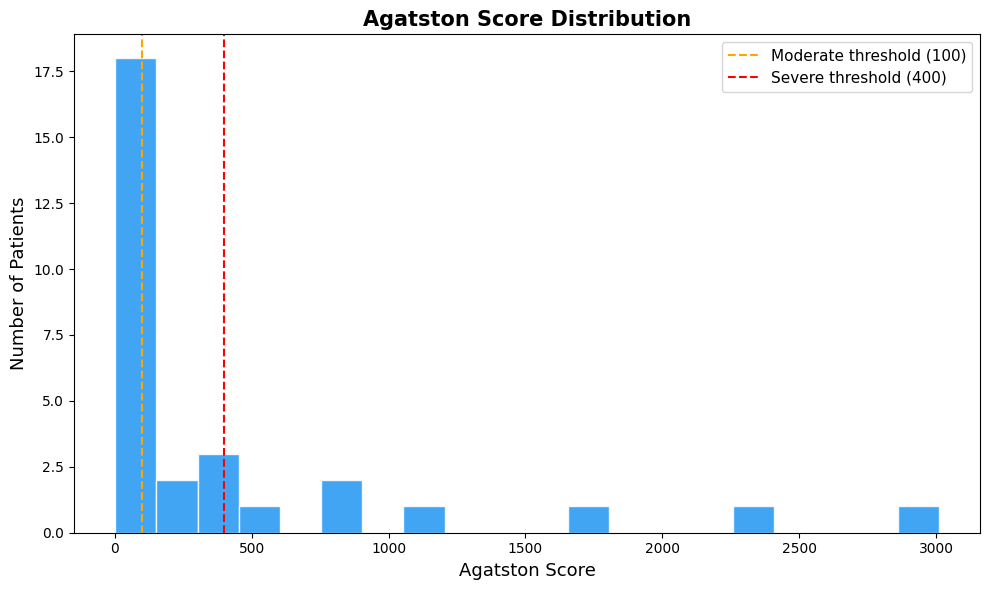

Saved: outputs/agatston_distribution.png


In [ ]:
# Agatston score distribution histogram 
fig, ax = plt.subplots(figsize=(10, 6))
scores = agatston_df['agatston_score'].values
ax.hist(scores, bins=20, color='#2196F3', edgecolor='white', alpha=0.85)
ax.set_xlabel('Agatston Score', fontsize=13)
ax.set_ylabel('Number of Patients', fontsize=13)
ax.set_title('Agatston Score Distribution', fontsize=15, fontweight='bold')
ax.axvline(x=100, color='orange', linestyle='--', label='Moderate threshold (100)')
ax.axvline(x=400, color='red', linestyle='--', label='Severe threshold (400)')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('outputs/agatston_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/agatston_distribution.png")

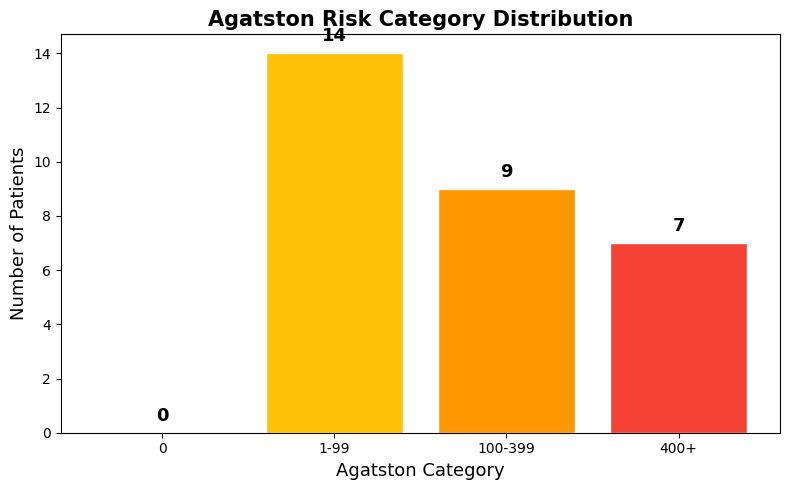

Saved: outputs/category_distribution.png


In [ ]:
# Category class balance bar chart
fig, ax = plt.subplots(figsize=(8, 5))
cat_order = ['0', '1-99', '100-399', '400+']
cat_counts_all = agatston_df['category'].value_counts().reindex(cat_order, fill_value=0)
colors = ['#4CAF50', '#FFC107', '#FF9800', '#F44336']
bars = ax.bar(cat_counts_all.index, cat_counts_all.values, color=colors, edgecolor='white')
for bar, count in zip(bars, cat_counts_all.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(count), ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.set_xlabel('Agatston Category', fontsize=13)
ax.set_ylabel('Number of Patients', fontsize=13)
ax.set_title('Agatston Risk Category Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/category_distribution.png")

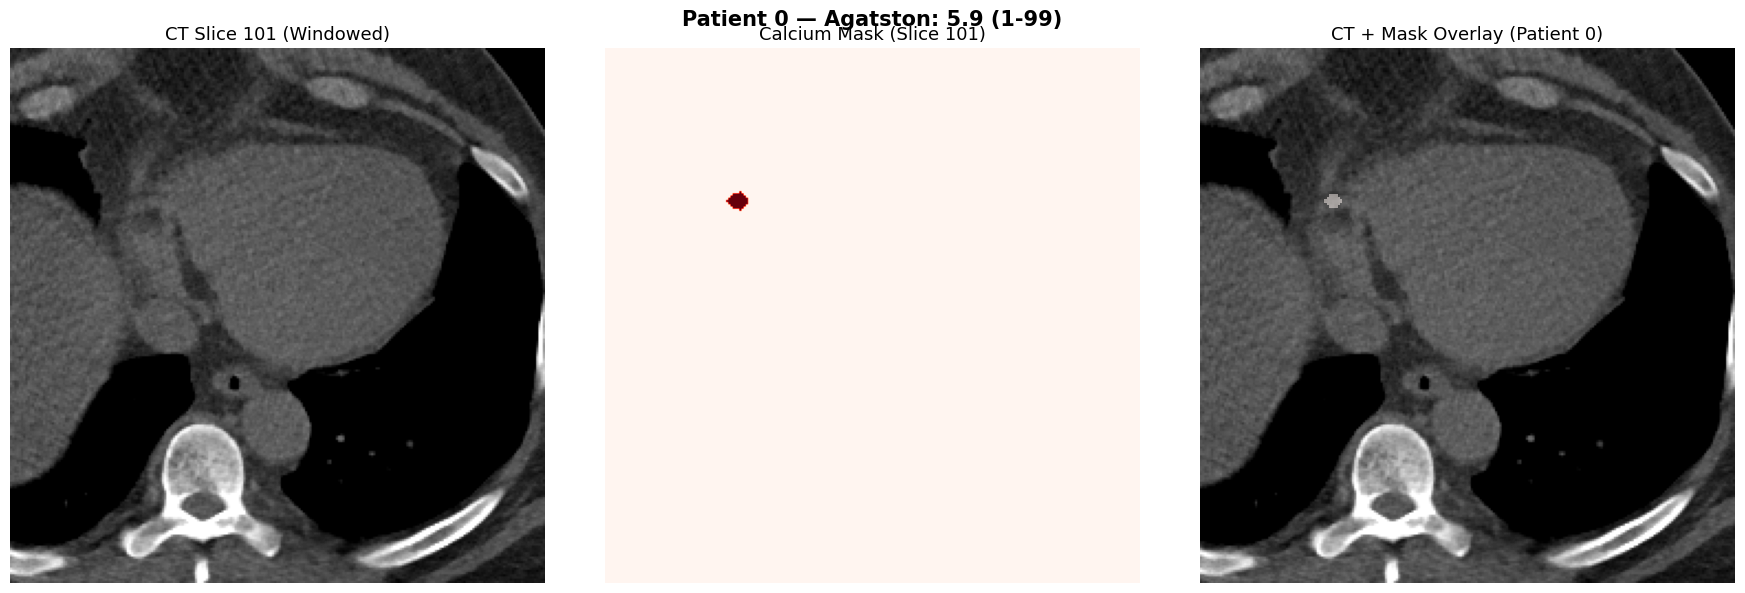

Saved: outputs/sample_slice_overlay.png


In [ ]:
# Sample axial slice with mask overlay

sample_pid = None
for pid in patient_ids:
    if pid in all_patient_data and all_patient_data[pid]['mask_nonzero'] > 0:
        sample_pid = pid
        break

if sample_pid is not None:
    d = all_patient_data[sample_pid]
    # Load from disk — only one patient at a time
    ct_wind = np.load(os.path.join(PREPROC_DIR, f'{sample_pid}_ct.npy'))
    mask_arr = np.load(os.path.join(PREPROC_DIR, f'{sample_pid}_mask.npy'))
    
    # Find slice with most calcium
    slice_sums = mask_arr.sum(axis=(1, 2))
    best_slice = np.argmax(slice_sums)
    
    from scipy.ndimage import binary_dilation

    # Dilate mask for DISPLAY ONLY — does not affect any calculations
    mask_display = binary_dilation(mask_arr[best_slice], iterations=3).astype(np.uint8)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Original CT
    axes[0].imshow(ct_wind[best_slice], cmap='gray')
    axes[0].set_title(f'CT Slice {best_slice} (Windowed)', fontsize=13)
    axes[0].axis('off')
    
    # Mask
    axes[1].imshow(mask_display, cmap='Reds')
    axes[1].set_title(f'Calcium Mask (Slice {best_slice})', fontsize=13)
    axes[1].axis('off')
    
    # Overlay
    axes[2].imshow(ct_wind[best_slice], cmap='gray')
    mask_overlay = np.ma.masked_where(mask_display == 0, mask_display)
    axes[2].imshow(mask_overlay, cmap='Reds', alpha=0.5)
    axes[2].set_title(f'CT + Mask Overlay (Patient {sample_pid})', fontsize=13)
    axes[2].axis('off')
    
    plt.suptitle(f'Patient {sample_pid} — Agatston: {d["agatston"]:.1f} ({d["category"]})',
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig('outputs/sample_slice_overlay.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: outputs/sample_slice_overlay.png")
    del ct_wind, mask_arr
else:
    print("No patient with non-empty mask found for visualization")

---
## Summary

This notebook implements a comprehensive end-to-end pipeline for coronary artery calcium (CAC) analysis and deep learning dataset preparation. Specifically, it:

1. Performs dynamic patient discovery by identifying the intersection of available DICOM image folders and corresponding XML annotation files.
2. Loads DICOM series with proper slice ordering based on `InstanceNumber`.
3. Parses XML annotations while filtering out empty or invalid regions of interest (ROIs).
4. Generates 3D binary segmentation masks from contour-based polygon annotations.
5. Applies Hounsfield Unit (HU) windowing (center = 150, width = 700) to standardize CT intensity values.
6. Resamples volumes and masks to isotropic 1.0 mm³ resolution (BSpline interpolation for CT images, Nearest Neighbor for masks).
7. Computes Agatston scores, including detailed per-artery calcium scoring.
8. Creates a stratified 70/15/15 train/validation/test split.
9. Addresses class imbalance using a WeightedRandomSampler strategy.
10. Constructs MONAI-based DataLoaders with radiomics-compatible data augmentations.
11. Generates comprehensive dataset statistics and visualizations for quality control and analysis.


**Outputs saved:**
- `outputs/agatston_scores.csv`
- `outputs/agatston_distribution.png`
- `outputs/category_distribution.png`
- `outputs/sample_slice_overlay.png`

**Next:** Run `notebook2_radiomics.ipynb` for PyRadiomics feature extraction and analysis.

## References

1. **Agatston Scoring Methodology:**  
   Agatston AS, Janowitz WR, Hildner FJ, et al. Quantification of coronary artery 
   calcium using ultrafast computed tomography. *JACC* 1990;15(4):827–832.  
   DOI: 10.1016/0735-1097(90)90282-T

2. **PyRadiomics:**  
   van Griethuysen JJM, Fedorov A, Parmar C, et al. Computational Radiomics System 
   to Decode the Radiographic Phenotype. *Cancer Research* 2017;77(21):e104–e107.  
   DOI: 10.1158/0008-5472.CAN-17-0339

3. **IBSI — Image Biomarker Standardisation Initiative:**  
   Zwanenburg A, Vallières M, Abdalah MA, et al. The Image Biomarker Standardization 
   Initiative. *Radiology* 2020;295(2):328–338.  
   DOI: 10.1148/radiol.2020191145

4. **COCA Dataset:**  
   Eng D, Chute C, Khandwala N, et al. Automated coronary calcium scoring using deep 
   learning with multicenter external validation. *npj Digital Medicine* 2021;4(1):88.  
   DOI: 10.1038/s41746-021-00460-1

5. **Cardiac CT Radiomics:**  
   Ayx I, Tharmaseelan H, Hertel A, et al. Radiomics in Cardiac Computed Tomography. 
   *Diagnostics* 2023;13(2):307.  
   DOI: 10.3390/diagnostics13020307